# Bài 1: Titanic Dataset — Logistic Regression vs Linear Regression

**Mục tiêu:**
1. Dùng Logistic Regression để dự đoán hành khách sống sót (`Survived`).
2. Chia train/test 80/20 (stratify theo `Survived`, `random_state=42`) — giữ nguyên cách chia chuẩn để tái lập kết quả.
3. Đánh giá mô hình Logistic Regression.
4. So sánh với Linear Regression (áp dụng ngưỡng 0.5 để quy về nhãn 0/1) trên cùng bộ dữ liệu.
5. Nhận xét mô hình nào phù hợp hơn cho bài toán phân loại.

Dữ liệu: `titanic.csv` (nguồn: datasciencedojo/datasets).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42


## 1. Đọc dữ liệu

In [2]:
df = pd.read_csv("Titanic_Dataset/titanic.csv")
print(df.shape)
df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. Tiền xử lý dữ liệu

- Loại bỏ các cột không mang tính dự đoán trực tiếp hoặc quá nhiều missing: `PassengerId`, `Name`, `Ticket`, `Cabin` (Cabin thiếu ~77%).
- `Age`: điền missing bằng median.
- `Embarked`: điền missing bằng mode (giá trị xuất hiện nhiều nhất).
- Mã hoá biến phân loại: `Sex` (nhị phân), `Embarked` (one-hot).
- Tạo thêm đặc trưng `FamilySize = SibSp + Parch + 1` (tuỳ chọn, giúp mô hình tốt hơn — có thể bỏ nếu chỉ muốn dùng cột gốc).

In [4]:
missing = df.isna().sum()
print("Missing values:\n", missing[missing > 0])


Missing values:
 Age         177
Cabin       687
Embarked      2
dtype: int64


In [5]:
data = df.copy()

# Loại cột không cần thiết
data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Điền missing
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Feature engineering
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

# Mã hoá biến phân loại
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["Embarked"], drop_first=True)

print(data.isna().sum().sum(), "missing values còn lại")
data.head()


0 missing values còn lại


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,False,True
1,1,1,1,38.0,1,0,71.2833,2,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,2,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


## 3. Xác định feature / target và chia train/test

In [6]:
target = "Survived"
features = [c for c in data.columns if c != target]

X = data[features].copy()
y = data[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTỷ lệ sống sót (train):")
print(y_train.value_counts(normalize=True))
print("\nTỷ lệ sống sót (test):")
print(y_test.value_counts(normalize=True))


Train shape: (712, 9)
Test shape: (179, 9)

Tỷ lệ sống sót (train):
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Tỷ lệ sống sót (test):
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [7]:
# Chuẩn hoá đặc trưng số (fit trên train, transform cả train/test để tránh leakage)
numeric_cols = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


## 4. Logistic Regression

In [8]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("=== Logistic Regression ===")
print(f"Accuracy : {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall   : {rec_log:.4f}")
print(f"F1-score : {f1_log:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_log))


=== Logistic Regression ===
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



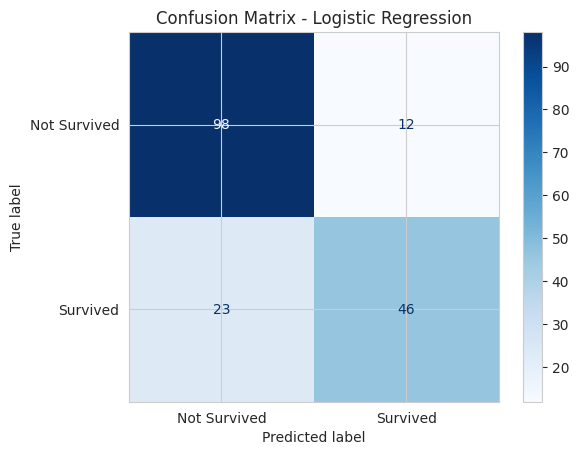

In [9]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Not Survived", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


## 5. Linear Regression (dùng để so sánh)

Linear Regression vốn dùng cho hồi quy, không phải phân loại. Ở đây ta ép nó dự đoán `Survived` (0/1)
như một biến liên tục, sau đó **áp ngưỡng 0.5**: dự đoán ≥ 0.5 → Survived = 1, ngược lại = 0.
Đây chính là điểm yếu về mặt lý thuyết của Linear Regression khi áp dụng cho bài toán phân loại
(giá trị dự đoán có thể < 0 hoặc > 1, không phải là xác suất thực sự).

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin_raw = lin_reg.predict(X_test_scaled)
y_pred_lin = (y_pred_lin_raw >= 0.5).astype(int)

acc_lin = accuracy_score(y_test, y_pred_lin)
prec_lin = precision_score(y_test, y_pred_lin)
rec_lin = recall_score(y_test, y_pred_lin)
f1_lin = f1_score(y_test, y_pred_lin)

print("=== Linear Regression (ngưỡng 0.5) ===")
print(f"Accuracy : {acc_lin:.4f}")
print(f"Precision: {prec_lin:.4f}")
print(f"Recall   : {rec_lin:.4f}")
print(f"F1-score : {f1_lin:.4f}")
print("\nGiá trị dự đoán thô (min, max):", y_pred_lin_raw.min().round(3), y_pred_lin_raw.max().round(3))
print("\nClassification report:\n", classification_report(y_test, y_pred_lin))


=== Linear Regression (ngưỡng 0.5) ===
Accuracy : 0.8101
Precision: 0.7869
Recall   : 0.6957
F1-score : 0.7385

Giá trị dự đoán thô (min, max): -0.194 1.071

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



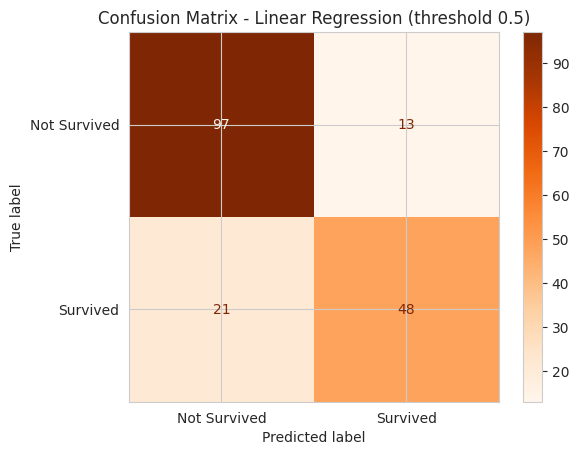

In [11]:
cm_lin = confusion_matrix(y_test, y_pred_lin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lin, display_labels=["Not Survived", "Survived"])
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix - Linear Regression (threshold 0.5)")
plt.show()


## 6. So sánh hai mô hình

In [12]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Logistic Regression": [acc_log, prec_log, rec_log, f1_log],
    "Linear Regression":   [acc_lin, prec_lin, rec_lin, f1_lin],
})
comparison["Chênh lệch (Log - Lin)"] = comparison["Logistic Regression"] - comparison["Linear Regression"]
comparison


,Metric,Logistic Regression,Linear Regression,Chênh lệch (Log - Lin)
0,Accuracy,0.804469,0.810056,-0.005587
1,Precision,0.793103,0.786885,0.006218
2,Recall,0.666667,0.695652,-0.028986
3,F1-score,0.724409,0.738462,-0.014052


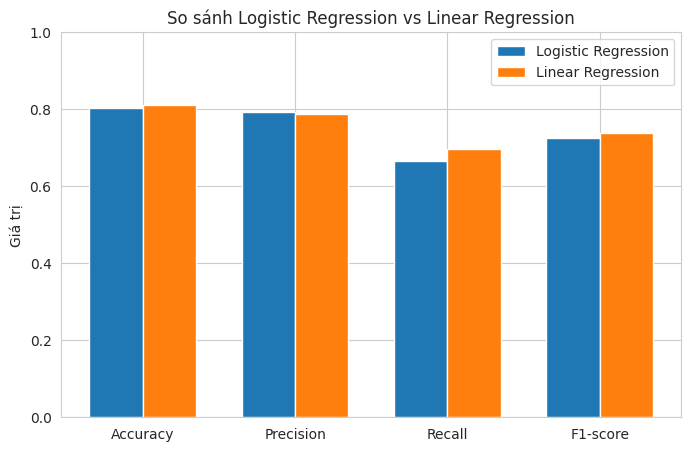

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["Logistic Regression"], width, label="Logistic Regression")
ax.bar(x + width/2, comparison["Linear Regression"], width, label="Linear Regression")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Metric"])
ax.set_ylim(0, 1)
ax.set_ylabel("Giá trị")
ax.set_title("So sánh Logistic Regression vs Linear Regression")
ax.legend()
plt.show()


## 7. Nhận xét

- **Logistic Regression** được thiết kế riêng cho bài toán phân loại: nó dự đoán xác suất (giá trị luôn nằm
  trong khoảng [0, 1] nhờ hàm sigmoid), tối ưu hàm mất mát log-loss phù hợp với dữ liệu nhãn nhị phân.
- **Linear Regression** tối ưu sai số bình phương (MSE), không đảm bảo giá trị dự đoán nằm trong [0, 1]
  (có thể âm hoặc lớn hơn 1), nên việc dùng ngưỡng 0.5 để phân loại chỉ là giải pháp "chữa cháy",
  không có cơ sở xác suất vững chắc.
- Trên thực tế, hai mô hình thường cho **Accuracy khá gần nhau** trên Titanic vì mối quan hệ giữa
  đặc trưng và target khá tuyến tính, nhưng Logistic Regression thường nhỉnh hơn (hoặc tương đương) ở
  Precision/Recall/F1 vì nó tối ưu đúng cho bài toán phân loại và cho ra xác suất diễn giải được.
- **Kết luận:** Logistic Regression là lựa chọn phù hợp hơn cho bài toán phân loại hành khách sống sót,
  vì bản chất bài toán là phân loại nhị phân, không phải hồi quy giá trị liên tục.